# 1. 导入库与环境配置

本节目标：

- 搭建项目运行环境
- 导入所有将使用的核心库
- 检测 GPU / CPU 运行设备
- 为后续实验做可复现性配置

本项目以“数字图像处理”为核心，因此本节主要导入：

- **图像处理库**：OpenCV、scikit-image
- **数据处理库**：numpy、pandas
- **可视化库**：matplotlib、seaborn
- **深度学习库（后面 CNN 会用）**：PyTorch 或 TensorFlow（二选一，这里使用 PyTorch）
- **系统库**：os、glob、pathlib

重点：图像在计算机中以矩阵形式表达，因此 numpy + cv2 是本项目的最基本依赖。

下面开始正式导库与环境检测。


PyTorch 版本: 2.7.1+cu118
CUDA 可用 ✓
GPU 名称: NVIDIA GeForce RTX 4060 Laptop GPU
当前计算设备: cuda
OpenCV 版本: 4.12.0


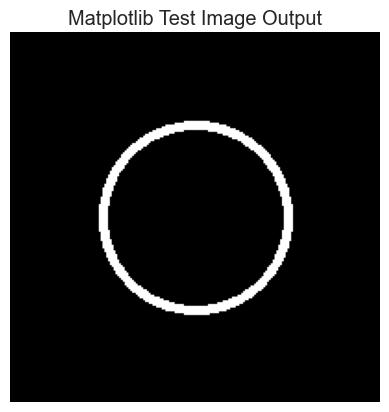

In [42]:
# ================================================
# Section 1 — 导入库与环境配置
# ================================================

# ----- 基础库 -----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
matplotlib.rcParams['axes.unicode_minus'] = False

import os
import sys
import numpy as np
import pandas as pd

# ----- 图像处理库 -----
import cv2
from skimage import io, color, filters, feature

# ----- 可视化库 -----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.2)

# ----- 深度学习库（用于 CNN） -----
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----- 实验可复现性 -----
import random

# 固定随机种子（保证每次结果一致）
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():          # 只有有 CUDA 才去设 CUDA 的种子
    torch.cuda.manual_seed_all(seed)

# ================================================
# 检查 PyTorch 和 GPU 环境
# ================================================
print("PyTorch 版本:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA 可用 ✓")
    print("GPU 名称:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("CUDA 不可用，使用 CPU（当前是 2.9.1+cpu 版本，这是正常的）")

print("当前计算设备:", device)

# ================================================
# 检查 OpenCV
# ================================================
print("OpenCV 版本:", cv2.__version__)

# 测试 matplotlib 图像输出
test_img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(test_img, (100, 100), 50, 255, 3)

plt.imshow(test_img, cmap='gray')
plt.title("Matplotlib Test Image Output")
plt.axis("off")
plt.show()


### 2. 数据加载与初步探索（Notebook）
- **目的**：读入 CelebA 的 CSV 标注 + 部分图像，了解数据。
- **实现内容**：
  - 读取：
    - `list_attr_celeba.csv`（40 个属性）
    - `list_landmarks_celeba.csv`（5 个关键点）
    - `list_bbox_celeba.csv`（人脸框）
    - `list_eval_partition.csv`（train/val/test 划分）
  - 展示：
    - 数据量统计、属性分布条形图；
    - 随机几张脸 + 对应属性。
- **知识点**：图像数据集结构、标注文件组织方式。
- **主要库**：`pandas, cv2/PIL, matplotlib`。
---

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ================================
# 2.1 路径配置 —— 适配当前目录结构|
# 当前工作目录：dazuoye/notebooks
# 数据目录：    dazuoye/data/archive
# ================================
# os.path.abspath("../archive") 将相对路径转为绝对路径，确保从 notebooks/ 目录向上找到 archive 数据目录
DATA_ROOT = os.path.abspath("../archive")
IMG_DIR   = os.path.join(DATA_ROOT, "img_align_celeba")  # CelebA 人脸对齐后的图像目录

# CelebA 数据集的四个标注 CSV 文件
ATTR_PATH = os.path.join(DATA_ROOT, "list_attr_celeba.csv")      # 40 个人脸属性标注
BBOX_PATH = os.path.join(DATA_ROOT, "list_bbox_celeba.csv")      # 人脸边界框标注 (x_1, y_1, width, height)
LAND_PATH = os.path.join(DATA_ROOT, "list_landmarks_align_celeba.csv")  # 5 个五官关键点坐标
PART_PATH = os.path.join(DATA_ROOT, "list_eval_partition.csv")    # 训练/验证/测试集划分

print("=== 路径确认 ===")
for p in [DATA_ROOT, IMG_DIR, ATTR_PATH, BBOX_PATH, LAND_PATH, PART_PATH]:
    print(f"{p:60s} -> {'OK' if os.path.exists(p) else 'NOT FOUND'}")

In [3]:
# CelebA 的这几个是逗号分隔的 CSV，不要再加 sep="\s+"

attr_df = pd.read_csv(ATTR_PATH)   # 40 个属性 + image_id
bbox_df = pd.read_csv(BBOX_PATH)   # image_id, x_1, y_1, width, height
land_df = pd.read_csv(LAND_PATH)   # image_id + 10 个关键点坐标
part_df = pd.read_csv(PART_PATH)   # image_id, partition

print("属性表 shape:", attr_df.shape)
print("bbox   shape:", bbox_df.shape)
print("landm  shape:", land_df.shape)
print("划分表 shape:", part_df.shape)

display(attr_df.head())
display(bbox_df.head())
display(land_df.head())
display(part_df.head())


属性表 shape: (202599, 41)
bbox   shape: (202599, 5)
landm  shape: (202599, 11)
划分表 shape: (202599, 2)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [4]:
# 看一眼列名确认一下
print(attr_df.columns.tolist())
print(bbox_df.columns.tolist())
print(land_df.columns.tolist())
print(part_df.columns.tolist())

# 为了统一命名，可以把 partition 列名改成 split（可选）
part_df = part_df.rename(columns={"partition": "split"})

# 合并四个表，得到一个总表 full_df
full_df = (
    attr_df
    .merge(bbox_df, on="image_id")
    .merge(land_df, on="image_id")
    .merge(part_df, on="image_id")
)

print("合并后 shape:", full_df.shape)
display(full_df.head())


['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
['image_id', 'x_1', 'y_1', 'width', 'height']
['image_id', 'lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y', 'nose_x', 'nose_y', 'leftmouth_x', 'leftmouth_y', 'rightmouth_x', 'rightmouth_y']
['image_id', 'partition']
合并后 shape: (202599, 56)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y,split
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,109,106,113,77,142,73,152,108,154,0
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,110,107,112,81,135,70,151,108,153,0
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,112,104,106,108,128,74,156,98,158,0
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,113,108,108,101,138,71,155,101,151,0
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,114,112,112,86,119,71,147,104,150,0


In [5]:
print("数据集划分统计（0=train, 1=val, 2=test）：")
split_counts = full_df["split"].value_counts().sort_index()
print(split_counts)


数据集划分统计（0=train, 1=val, 2=test）：
split
0    162770
1     19867
2     19962
Name: count, dtype: int64


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 路径配置 =========
# 原始人脸图像目录（与你项目一致）
IMG_DIR = IMG_DIR  # 若未定义，可改成 r"data/archive/img_align_celeba"

# 结果保存目录（SCI 论文用图统一存放）
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)  # exist_ok=True 表示目录已存在时不报错

# ========= 随机选一张图 =========
sample = full_df.sample(1, random_state=0).iloc[0]  # random_state=0 保证可复现
img_path = os.path.join(IMG_DIR, sample["image_id"])
print("示例图片：", img_path)

# ========= 读取图像 =========
img = cv2.imread(img_path)                    # 以 BGR 模式读取
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # BGR 转 RGB（matplotlib 显示需要）

# ========= 可视化 =========
plt.figure(figsize=(5, 5))
plt.imshow(img)

# --- 画 bbox ---
x, y, w, h = sample[["x_1", "y_1", "width", "height"]]  # 从 DataFrame 取边界框参数
plt.gca().add_patch(
    plt.Rectangle((x, y), w, h, fill=False, linewidth=2)  # 绘制矩形边框，仅描边不填充
)

# --- 画五官关键点 ---
for lx, ly in [
    ("lefteye_x", "lefteye_y"),      # 左眼
    ("righteye_x", "righteye_y"),    # 右眼
    ("nose_x", "nose_y"),            # 鼻尖
    ("leftmouth_x", "leftmouth_y"),  # 左嘴角
    ("rightmouth_x", "rightmouth_y"),# 右嘴角
]:
    plt.scatter(sample[lx], sample[ly], s=20)  # scatter 散点图标记关键点

plt.axis("off")
plt.title(f"Bounding box & landmarks\n{sample['image_id']}")

# ========= 保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_bbox_landmarks_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(save_path, dpi=200, bbox_inches="tight")  # dpi=200 用于日常查看，论文用 dpi>=400
plt.show()

print("已保存到：", save_path)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ========= 读取图像 =========
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]  # 图像高度和宽度

# ========= 取 5 个关键点 =========
pts = np.array([
    [sample["lefteye_x"],   sample["lefteye_y"]],    # 左眼坐标
    [sample["righteye_x"],  sample["righteye_y"]],   # 右眼坐标
    [sample["nose_x"],      sample["nose_y"]],        # 鼻尖坐标
    [sample["leftmouth_x"], sample["leftmouth_y"]],   # 左嘴角坐标
    [sample["rightmouth_x"],sample["rightmouth_y"]],  # 右嘴角坐标
], dtype=float)

# ========= 用关键点计算 bbox（并扩展 30%）=========
x_min, y_min = pts.min(axis=0)  # 所有关键点的最小 x/y
x_max, y_max = pts.max(axis=0)  # 所有关键点的最大 x/y

w = x_max - x_min  # 关键点包围盒宽度
h = y_max - y_min  # 关键点包围盒高度
p = 0.30  # 扩展比例（30%），留出额头和下巴区域

x0 = x_min - p * w  # 向左扩展
y0 = y_min - p * h  # 向上扩展（额头方向）
x1 = x_max + p * w  # 向右扩展
y1 = y_max + p * h  # 向下扩展（下巴方向）

# clamp 到图像边界，防止坐标越界
x0 = int(max(0, np.floor(x0)))
y0 = int(max(0, np.floor(y0)))
x1 = int(min(W - 1, np.ceil(x1)))
y1 = int(min(H - 1, np.ceil(y1)))

bbox_w = x1 - x0
bbox_h = y1 - y0

# ========= 论文级绘图（居中显示 bbox 区域）=========
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img)

# bbox（红色矩形边框）
ax.add_patch(
    plt.Rectangle((x0, y0), bbox_w, bbox_h,
                  fill=False, edgecolor="red", linewidth=2.5)
)

# landmarks（语义分色：不同五官用不同颜色区分）
ax.scatter(pts[0:2,0], pts[0:2,1], s=55, c="cyan",  edgecolors="black", linewidths=0.5, zorder=3)  # 眼睛=青色
ax.scatter(pts[2,0],   pts[2,1],   s=55, c="yellow",edgecolors="black", linewidths=0.5, zorder=3)  # 鼻子=黄色
ax.scatter(pts[3:5,0], pts[3:5,1], s=55, c="lime",  edgecolors="black", linewidths=0.5, zorder=3)  # 嘴巴=绿色

# 关键：把视野缩放到 bbox 周围 → 人脸自动居中显示
m = int(0.15 * max(bbox_w, bbox_h))  # 额外留白（15%），避免边框紧贴图像边缘
xl0 = max(0, x0 - m); xl1 = min(W, x1 + m)
yl0 = max(0, y0 - m); yl1 = min(H, y1 + m)

ax.set_xlim(xl0, xl1)
ax.set_ylim(yl1, yl0)   # 注意：imshow 的 y 轴向下，所以 ylim 上下反转

ax.set_title("Face bounding box and landmarks", fontsize=11)
ax.axis("off")

# ========= SCI 论文级高清保存 =========
save_path = os.path.join("results", "fig_bbox_landmarks.png")
plt.savefig(save_path, dpi=400, bbox_inches="tight")  # dpi=400 满足 SCI 期刊 300+ PPI 要求
plt.show()

print("论文图已保存：", save_path)

In [ ]:
import os
import matplotlib.pyplot as plt

# ========= 保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 选择属性 =========
attr_cols = ["Male", "Smiling", "Young", "Wearing_Hat", "Eyeglasses"]  # 选取 5 个有代表性的属性

# CelebA 属性值是 -1/1，需要转换为 0/1 以便计算正例比例
attr_bin = full_df[attr_cols].replace({-1: 0, 1: 1})

# 计算每个属性的正例比例（mean 即为正例占比），并按降序排列
pos_rates = attr_bin.mean().sort_values(ascending=False)
print("各属性正例比例：")
print(pos_rates)

# ========= 画图 =========
plt.figure(figsize=(6, 4))  # SCI 论文常用比例
pos_rates.plot(kind="bar", color="#4C72B0")  # 统一蓝色配色

plt.ylabel("Positive Ratio", fontsize=11)
plt.xlabel("Attribute", fontsize=11)
plt.title("Distribution of Selected CelebA Attributes", fontsize=12)

plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)  # y 轴方向虚线网格
plt.xticks(rotation=30)  # 旋转 30 度避免标签重叠

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    "fig_attribute_distribution.png"
)

plt.savefig(
    save_path,
    dpi=400,              # SCI 论文要求 dpi >= 300
    bbox_inches="tight"   # 去除多余白边
)

plt.show()

print("已保存高清图像：", save_path)

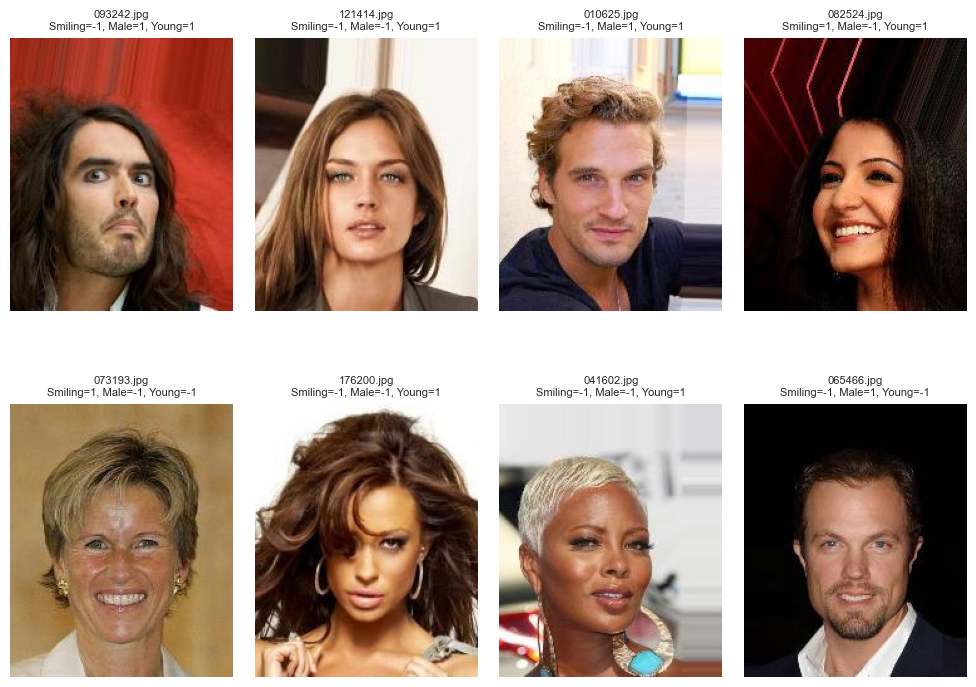

已保存高清图像： results\fig_sample_faces_with_attributes.png


In [8]:
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# ========= 路径配置 =========
IMG_DIR = Path("../archive/img_align_celeba")   # 按你当前 Notebook 所在路径
RESULT_DIR = Path("results")
RESULT_DIR.mkdir(exist_ok=True)

# ========= 随机抽样 =========
samples = full_df.sample(8, random_state=42)
show_attrs = ["Smiling", "Male", "Young"]  # 标题中展示的属性

# ========= 可视化 =========
plt.figure(figsize=(10, 8))

for i, (_, row) in enumerate(samples.iterrows()):
    img_path = IMG_DIR / row["image_id"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # 属性值显示（0/1 已在前面处理过）
    attr_text = ", ".join(
        [f"{col}={int(row[col])}" for col in show_attrs]
    )

    plt.title(
        f"{row['image_id']}\n{attr_text}",
        fontsize=8
    )

plt.tight_layout()

# ========= 高清保存 =========
save_path = RESULT_DIR / "fig_sample_faces_with_attributes.png"
plt.savefig(
    save_path,
    dpi=400,                 # 👈 SCI 级清晰度
    bbox_inches="tight"
)

plt.show()

print("已保存高清图像：", save_path)



### 3. 图像几何变换与对齐（Notebook）

- **目的**：做人脸对齐/裁剪/缩放，兼顾数据增强。
- **实现内容**：
  - 根据 bbox 裁剪人脸区域。
  - 根据两眼关键点估算旋转，做仿射对齐（旋正）。
  - 统一缩放到固定尺寸（如 128×128 或 224×224）。
  - 做若干几何增强示例：旋转、水平翻转等。
- **知识点**：仿射变换、插值、数据增强对模型的作用。
- **主要库**：`cv2.getRotationMatrix2D, cv2.warpAffine, cv2.resize, cv2.flip`。
### 4. 图像滤波与去噪（Notebook）

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# 如果上面已经定义过 IMG_DIR，这里可以注释掉
# IMG_DIR = Path("../data/archive/img_align_celeba")

def load_image(row):
    """根据 full_df 的一行记录读取原始图像(BGR)"""
    img_path = IMG_DIR / row["image_id"]  # Path 对象拼接路径
    img = cv2.imread(str(img_path))       # imread 需要字符串路径
    if img is None:
        raise ValueError(f"图像读取失败: {img_path}")
    return img


def show_rgb(img, title=None, ax=None):
    """安全显示 BGR 图像：自动处理空图像和色彩转换"""
    if ax is None:
        plt.figure(figsize=(4, 4))
        ax = plt.gca()
    if img is None or img.size == 0:  # 空图像时显示占位文字
        ax.text(0.5, 0.5, "空图像", ha="center", va="center")
        ax.axis("off")
        if title:
            ax.set_title(title)
        return ax
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # BGR→RGB 转换（matplotlib 要求 RGB）
    ax.axis("off")
    if title:
        ax.set_title(title)
    return ax


# 让中文标题不报错（可选）
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['SimHei']    # 设置黑体字体，支持中文显示
matplotlib.rcParams['axes.unicode_minus'] = False       # 解决负号显示为方块的问题

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)


def compute_bbox_from_landmarks(row, img_shape, expand_ratio=0.3):
    """
    利用 5 个关键点自动生成人脸 bbox，并适当扩边
    expand_ratio: 在关键点包围盒基础上进行扩展的比例
    """
    h, w = img_shape[:2]

    # 提取 5 个关键点的 x/y 坐标
    xs = np.array([
        row["lefteye_x"],
        row["righteye_x"],
        row["nose_x"],
        row["leftmouth_x"],
        row["rightmouth_x"],
    ], dtype=np.float32)

    ys = np.array([
        row["lefteye_y"],
        row["righteye_y"],
        row["nose_y"],
        row["leftmouth_y"],
        row["rightmouth_y"],
    ], dtype=np.float32)

    x_min, x_max = xs.min(), xs.max()  # 关键点水平范围
    y_min, y_max = ys.min(), ys.max()  # 关键点垂直范围

    # 计算中心点和扩展后的宽高
    cx = (x_min + x_max) / 2   # 包围盒中心 x
    cy = (y_min + y_max) / 2   # 包围盒中心 y
    bw = (x_max - x_min) * (1 + expand_ratio)            # 水平扩展
    bh = (y_max - y_min) * (1 + expand_ratio * 1.2)      # 竖直方向略微放大（多留额头和下巴）

    # np.clip 裁剪到图像有效范围内
    x1 = int(np.clip(cx - bw / 2, 0, w - 1))
    y1 = int(np.clip(cy - bh / 2, 0, h - 1))
    x2 = int(np.clip(cx + bw / 2, x1 + 1, w))
    y2 = int(np.clip(cy + bh / 2, y1 + 1, h))

    return x1, y1, x2, y2


def crop_face_auto(img, row, expand_ratio=0.3):
    """根据关键点自动估计 bbox 并裁剪人脸区域"""
    x1, y1, x2, y2 = compute_bbox_from_landmarks(row, img.shape, expand_ratio)
    face = img[y1:y2, x1:x2].copy()  # NumPy 数组切片裁剪
    return face, (x1, y1, x2, y2)


# ========= 测试示例：原图 + 自动 bbox =========
sample = full_df.sample(1, random_state=0).iloc[0]
img_raw = load_image(sample)  # BGR 格式
face_crop, (x1, y1, x2, y2) = crop_face_auto(img_raw, sample, expand_ratio=0.3)

# ========= 可视化 =========
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

show_rgb(img_raw, "Original Image", ax=axes[0])

# 在原图上画自动 bbox（红色矩形）
img_box = img_raw.copy()
cv2.rectangle(img_box, (x1, y1), (x2, y2), (0, 0, 255), 2)  # BGR: (0,0,255)=红色, 线宽=2
show_rgb(img_box, "Auto-generated Bounding Box", ax=axes[1])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_auto_bbox_from_landmarks_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"      # 去除多余白边
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)


def align_face_by_eyes(img, row, output_size=(128, 128), expand_ratio=0.3):
    """
    人脸对齐流水线：
    1. 基于五官关键点自动生成人脸 bbox 并裁剪
    2. 根据双眼连线估计旋转角度并进行仿射对齐（把歪的人脸旋正）
    3. resize 到统一尺寸（便于后续 CNN 输入）
    """
    face, (x1, y1, x2, y2) = crop_face_auto(img, row, expand_ratio)
    fh, fw = face.shape[:2]  # 裁剪后人脸的高/宽

    # 将关键点坐标转换为裁剪后人脸区域的相对坐标
    lx = row["lefteye_x"] - x1   # 左眼 x（相对于裁剪区域）
    ly = row["lefteye_y"] - y1   # 左眼 y
    rx = row["righteye_x"] - x1  # 右眼 x
    ry = row["righteye_y"] - y1  # 右眼 y

    # 计算双眼连线的角度（arctan2 返回弧度值，转换为角度）
    dy = ry - ly    # 双眼垂直差
    dx = rx - lx    # 双眼水平差
    angle = np.degrees(np.arctan2(dy, dx))  # 双眼连线相对于水平线的倾斜角度
    center = ((lx + rx) / 2.0, (ly + ry) / 2.0)  # 旋转中心 = 两眼连线中点

    # 仿射旋转：取反角度使双眼连线变为水平
    M = cv2.getRotationMatrix2D(center, -angle, 1.0)  # scale=1.0 不缩放
    face_aligned = cv2.warpAffine(
        face, M, (fw, fh), flags=cv2.INTER_LINEAR  # INTER_LINEAR 双线性插值
    )

    # resize 到统一尺寸（如 128x128 或 224x224）
    face_resized = cv2.resize(
        face_aligned, output_size, interpolation=cv2.INTER_LINEAR
    )

    return face_resized


# ========= 效果演示 =========
sample = full_df.sample(1, random_state=1).iloc[0]
img_raw = load_image(sample)  # BGR

face_crop, _ = crop_face_auto(img_raw, sample, expand_ratio=0.3)
face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128), expand_ratio=0.3
)

# ========= 可视化 =========
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

show_rgb(img_raw, "Original Image", ax=axes[0])
show_rgb(face_crop, "Auto BBox Crop", ax=axes[1])
show_rgb(face_aligned, "Aligned & Resized (128x128)", ax=axes[2])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_face_alignment_pipeline_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)


def augment_geometric(img, angle=15):
    """
    对齐后人脸进行几何数据增强：
    - 小角度随机旋转（模拟头部微倾）
    - 水平翻转（模拟左右脸镜像）
    """
    h, w = img.shape[:2]
    center = (w / 2, h / 2)  # 旋转中心 = 图像中心

    # 旋转：绕图像中心旋转指定角度
    M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)  # (中心, 角度, 缩放比)
    img_rot = cv2.warpAffine(
        img, M_rot, (w, h), flags=cv2.INTER_LINEAR
    )

    # 水平翻转：flipCode=1 表示沿 y 轴翻转（左右镜像）
    img_flip = cv2.flip(img, 1)

    return img_rot, img_flip


# ========= 示例演示 =========
sample = full_df.sample(1, random_state=2).iloc[0]
img_raw = load_image(sample)

face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)
rot_img, flip_img = augment_geometric(face_aligned, angle=15)

# ========= 可视化 =========
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

show_rgb(face_aligned, "Aligned Face", ax=axes[0])
show_rgb(rot_img, "Rotation (+15 deg)", ax=axes[1])
show_rgb(flip_img, "Horizontal Flip", ax=axes[2])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_geometric_augmentation_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 示例样本 =========
sample = full_df.sample(1, random_state=42).iloc[0]
img_raw = load_image(sample)  # BGR

# 人脸处理流水线：裁剪 → 对齐 → 几何增强
face_crop, _ = crop_face_auto(img_raw, sample, expand_ratio=0.3)
face_aligned = align_face_by_eyes(img_raw, sample, output_size=(128, 128))
rot_img, flip_img = augment_geometric(face_aligned, angle=20)

# ========= 可视化（4 步流水线对比） =========
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

show_rgb(img_raw, "Original Image", ax=axes[0])
show_rgb(face_crop, "Auto BBox Crop", ax=axes[1])
show_rgb(face_aligned, "Aligned & Resized (128x128)", ax=axes[2])
show_rgb(rot_img, "Rotation (+20 deg)", ax=axes[3])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_geometric_processing_pipeline_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级分辨率
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

- **目的**：演示空域滤波：降噪 + 锐化。
- **实现内容**：
  - 高斯滤波 / 均值滤波 / 中值滤波对比。
  - 拉普拉斯或自定义卷积核做锐化。
  - 展示“原图 vs 模糊 vs 锐化”对比。
- **知识点**：卷积、低通/高通滤波，噪声-细节的权衡。
- **主要库**：`cv2.GaussianBlur, cv2.medianBlur, cv2.filter2D`。

---

In [ ]:
import os
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机挑一张样本 =========
sample = full_df.sample(1, random_state=123).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)  # BGR
face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= 可视化：原图 vs 对齐人脸 =========
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

show_rgb(img_raw, "Original Image", ax=axes[0])
show_rgb(face_aligned, "Aligned Face (128x128)", ax=axes[1])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_original_vs_aligned_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级分辨率
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机挑一张样本 =========
sample = full_df.sample(1, random_state=123).iloc[0]

# 原图 + 对齐人脸
img_raw = load_image(sample)   # BGR
face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= 空域滤波（三种经典低通滤波对比） =========
# 高斯滤波：加权平均，离中心越近权重越大，平滑同时保留一定结构
gauss = cv2.GaussianBlur(face_aligned, ksize=(5, 5), sigmaX=1.0)
# ksize=(5,5): 5x5 高斯核；sigmaX=1.0: 高斯分布标准差

# 均值滤波（box filter）：所有邻域像素等权重平均，模糊效果更强
mean = cv2.blur(face_aligned, ksize=(5, 5))

# 中值滤波：取邻域像素的中值，对椒盐噪声特别鲁棒
median = cv2.medianBlur(face_aligned, ksize=5)  # ksize 必须为奇数

# ========= 可视化 =========
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

show_rgb(face_aligned, "Aligned Face", ax=axes[0])
show_rgb(gauss, "Gaussian Blur", ax=axes[1])
show_rgb(mean, "Mean Filter", ax=axes[2])
show_rgb(median, "Median Filter", ax=axes[3])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_spatial_filtering_comparison_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机挑一张样本 =========
sample = full_df.sample(1, random_state=123).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= 锐化（拉普拉斯风格卷积核） =========
# 中心为 5、四周为 -1 的 3x3 核：增强边缘对比度
# 等效于 "原图 + (原图 - 高斯模糊)" 的效果
sharp_kernel = np.array([
    [0, -1,  0],
    [-1,  5, -1],
    [0, -1,  0]
], dtype=np.float32)

# filter2D: 二维卷积滤波
# ddepth=-1 表示输出深度与输入相同
sharp = cv2.filter2D(
    face_aligned, ddepth=-1, kernel=sharp_kernel
)

# ========= 可视化 =========
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

show_rgb(face_aligned, "Aligned Face", ax=axes[0])
show_rgb(sharp, "Sharpened Image", ax=axes[1])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_image_sharpening_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机挑一张样本 =========
sample = full_df.sample(1, random_state=123).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face_aligned = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= Unsharp Mask（反锐化掩膜锐化） =========
# 原理：锐化 = 原图 + (原图 - 模糊图) = 2*原图 - 模糊图
# 先做较强的高斯模糊（sigma=2.0 较大，模糊更明显）
blur_strong = cv2.GaussianBlur(
    face_aligned, (0, 0), sigmaX=2.0  # (0,0) 表示核大小由 sigma 自动计算
)

# addWeighted: 加权混合，alpha=1.5, beta=-0.5
# 公式：result = 1.5 * 原图 - 0.5 * 模糊图 = 原图 + 0.5 * (原图 - 模糊图)
unsharp = cv2.addWeighted(
    face_aligned, 1.5, blur_strong, -0.5, 0  # gamma=0 偏移量
)

# ========= 可视化 =========
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

show_rgb(face_aligned, "Aligned Face", ax=axes[0])
show_rgb(blur_strong, "Strong Gaussian Blur", ax=axes[1])
show_rgb(unsharp, "Unsharp Mask Sharpening", ax=axes[2])

plt.tight_layout()

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_unsharp_mask_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级分辨率
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
# ===== Figure 6: 空域滤波与增强效果对比（论文级排版） =====
import matplotlib.pyplot as plt

# 假设你前面已经算好了这些变量：
# face_aligned, gauss, mean, median, sharp, unsharp

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))  # 2x2 排版，控制尺寸防止过宽

# (a) 原始对齐人脸
axes[0, 0].imshow(cv2.cvtColor(face_aligned, cv2.COLOR_BGR2RGB))  # BGR→RGB
axes[0, 0].set_title("(a) Aligned face", fontsize=10)
axes[0, 0].axis("off")

# (b) 高斯滤波（选代表性的一种，避免太杂）
axes[0, 1].imshow(cv2.cvtColor(gauss, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("(b) Gaussian filtering", fontsize=10)
axes[0, 1].axis("off")

# (c) 拉普拉斯锐化
axes[1, 0].imshow(cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("(c) Laplacian-based sharpening", fontsize=10)
axes[1, 0].axis("off")

# (d) Unsharp Mask 增强
axes[1, 1].imshow(cv2.cvtColor(unsharp, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("(d) Unsharp mask enhancement", fontsize=10)
axes[1, 1].axis("off")

plt.tight_layout()

# ===== SCI 级保存 =====
plt.savefig(
    "./results/Figure_6_spatial_filtering_and_enhancement.png",
    dpi=400,                    # 400 PPI 满足 SCI 期刊要求
    bbox_inches="tight",        # 去除多余白边
    pad_inches=0.02             # 期刊安全边距
)

plt.show()

- **目的**：演示空域滤波：降噪 + 锐化。
- **实现内容**：
  - 高斯滤波 / 均值滤波 / 中值滤波对比。
  - 拉普拉斯或自定义卷积核做锐化。
  - 展示“原图 vs 模糊 vs 锐化”对比。
- **知识点**：卷积、低通/高通滤波，噪声-细节的权衡。
- **主要库**：`cv2.GaussianBlur, cv2.medianBlur, cv2.filter2D`。

---
### 5. 直方图处理与图像增强（Notebook）
- **目的**：用直方图均衡化改善对比度，减轻光照差异。
- **实现内容**：
  - 灰度图直方图均衡化。
  - 彩色图：只对亮度通道做 HE 或 CLAHE。
  - 绘制均衡前后直方图和图像效果。
- **知识点**：灰度变换、CDF、全局 vs 自适应均衡。
- **主要库**：`cv2.equalizeHist, cv2.createCLAHE, skimage.exposure`。
---

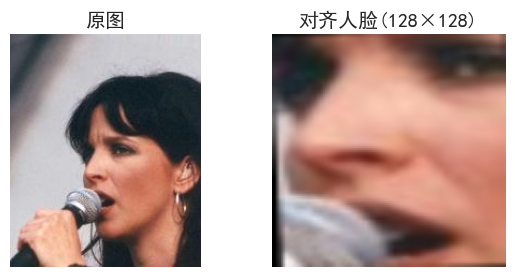

In [18]:

from skimage import exposure  # 后面可选用一下

sample = full_df.sample(1, random_state=2025).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(img_raw, "原图", ax=ax[0])
show_rgb(face, "对齐人脸(128×128)", ax=ax[1])
plt.tight_layout()
plt.show()


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机样本（与上一节保持一致） =========
sample = full_df.sample(1, random_state=2025).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= 灰度直方图均衡化 =========
face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)  # 彩色转灰度

# OpenCV 全局直方图均衡化：将灰度值重新映射，使直方图近似均匀分布
face_gray_he = cv2.equalizeHist(face_gray)  # 输入输出均为 uint8

# ========= 可视化（2x2 排版：图像 + 直方图） =========
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

# 上排：原灰度图 vs 均衡化后灰度图
axes[0, 0].imshow(face_gray, cmap="gray")
axes[0, 0].set_title("Grayscale Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(face_gray_he, cmap="gray")
axes[0, 1].set_title("Histogram Equalization")
axes[0, 1].axis("off")

# 下排：对应直方图（ravel 将二维展平为一维）
axes[1, 0].hist(
    face_gray.ravel(),        # 展平像素值
    bins=64,                  # 64 个 bin（比 256 更清晰）
    range=(0, 256),
    color="black",
    alpha=0.9
)
axes[1, 0].set_title("Histogram (Original)")
axes[1, 0].set_xlim(0, 255)
axes[1, 0].set_yscale("log")  # 对数尺度：小数量级的 bin 也能看清
axes[1, 0].set_ylabel("Pixel count")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(
    face_gray_he.ravel(),
    bins=64,
    range=(0, 256),
    color="black",
    alpha=0.9
)
axes[1, 1].set_title("Histogram (Equalized)")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].set_yscale("log")
axes[1, 1].grid(alpha=0.3)

# ========= 高清保存 =========
save_path = os.path.join(
    RESULT_DIR,
    f"fig_histogram_equalization_gray_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机样本 =========
sample = full_df.sample(1, random_state=2025).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= 彩色图像亮度直方图均衡 =========
# BGR -> YCrCb 颜色空间：Y=亮度, Cr/Cb=色度分量
ycrcb = cv2.cvtColor(face, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)  # 拆分为三个单通道

# 仅对亮度通道 Y 做 HE，保持色度不变（避免颜色失真）
Y_he = cv2.equalizeHist(Y)

# 合并三个通道并转回 BGR
ycrcb_he = cv2.merge([Y_he, Cr, Cb])  # 用均衡化后的 Y 替换原 Y
face_color_he = cv2.cvtColor(ycrcb_he, cv2.COLOR_YCrCb2BGR)

# ========= 彩色图像对比显示 =========
fig1, axes1 = plt.subplots(1, 2, figsize=(6, 3))

show_rgb(face, "Original Color Image", ax=axes1[0])
show_rgb(face_color_he, "Luminance Equalized (Y Channel)", ax=axes1[1])

plt.tight_layout()

save_path_img = os.path.join(
    RESULT_DIR,
    f"fig_color_luminance_equalization_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_img,
    dpi=400,                 # SCI 级清晰度
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path_img)

# ========= 亮度直方图对比（改进版） =========
fig2, axes2 = plt.subplots(1, 2, figsize=(8, 3))

# 原始 Y 通道直方图
axes2[0].hist(
    Y.ravel(),               # 展平像素值
    bins=64,                  # 减少 bin 数使直方图更清晰
    range=(0, 256),
    color="black",
    alpha=0.9
)
axes2[0].set_title("Histogram of Y Channel (Original)")
axes2[0].set_xlim(0, 255)
axes2[0].set_yscale("log")   # 对数尺度避免高 bin 遮挡低 bin
axes2[0].set_ylabel("Pixel count")
axes2[0].grid(alpha=0.3)

# 均衡化后 Y 通道直方图
axes2[1].hist(
    Y_he.ravel(),
    bins=64,
    range=(0, 256),
    color="black",
    alpha=0.9
)
axes2[1].set_title("Histogram of Y Channel (Equalized)")
axes2[1].set_xlim(0, 255)
axes2[1].set_yscale("log")
axes2[1].grid(alpha=0.3)

plt.tight_layout()

save_path_hist = os.path.join(
    RESULT_DIR,
    f"fig_color_luminance_histogram_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_hist,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
print("已保存高清直方图：", save_path_hist)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机样本 =========
sample = full_df.sample(1, random_state=2025).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= YCrCb 颜色空间 =========
ycrcb = cv2.cvtColor(face, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

# ========= 全局 HE（直方图均衡化） =========
Y_he = cv2.equalizeHist(Y)
ycrcb_he = cv2.merge([Y_he, Cr, Cb])
face_color_he = cv2.cvtColor(ycrcb_he, cv2.COLOR_YCrCb2BGR)

# ========= CLAHE（对比度受限自适应直方图均衡化） =========
# 相比全局 HE，CLAHE 在局部区域（8x8 tile）分别均衡化
# clipLimit=2.0 限制对比度增益，防止过增强噪声
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
Y_clahe = clahe.apply(Y)  # 对亮度通道应用 CLAHE
ycrcb_clahe = cv2.merge([Y_clahe, Cr, Cb])
face_color_clahe = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2BGR)

# ========= 彩色图像对比（三图并排） =========
fig1, axes1 = plt.subplots(1, 3, figsize=(9, 3))

show_rgb(face, "Original Color Image", ax=axes1[0])
show_rgb(face_color_he, "Global HE (Y Channel)", ax=axes1[1])
show_rgb(face_color_clahe, "CLAHE (Y Channel)", ax=axes1[2])

plt.tight_layout()

save_path_img = os.path.join(
    RESULT_DIR,
    f"fig_he_vs_clahe_color_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_img,
    dpi=400,                 # SCI 级分辨率
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path_img)

# ========= 亮度直方图对比 =========
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3))

axes2[0].hist(Y.ravel(), bins=256, range=(0, 256))
axes2[0].set_title("Histogram of Y (Original)")

axes2[1].hist(Y_he.ravel(), bins=256, range=(0, 256))
axes2[1].set_title("Histogram of Y (Global HE)")

axes2[2].hist(Y_clahe.ravel(), bins=256, range=(0, 256))
axes2[2].set_title("Histogram of Y (CLAHE)")

plt.tight_layout()

save_path_hist = os.path.join(
    RESULT_DIR,
    f"fig_he_vs_clahe_histogram_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_hist,
    dpi=400,                 # SCI 级分辨率
    bbox_inches="tight"
)

plt.show()
print("已保存高清直方图：", save_path_hist)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ========= 结果保存目录 =========
RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ========= 随机样本 =========
sample = full_df.sample(1, random_state=2025).iloc[0]

# 原图 + 对齐后人脸
img_raw = load_image(sample)   # BGR
face = align_face_by_eyes(
    img_raw, sample, output_size=(128, 128)
)

# ========= YCrCb 颜色空间 =========
ycrcb = cv2.cvtColor(face, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

# ========= 全局 HE =========
Y_he = cv2.equalizeHist(Y)
ycrcb_he = cv2.merge([Y_he, Cr, Cb])
face_color_he = cv2.cvtColor(ycrcb_he, cv2.COLOR_YCrCb2BGR)

# ========= CLAHE =========
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
Y_clahe = clahe.apply(Y)
ycrcb_clahe = cv2.merge([Y_clahe, Cr, Cb])
face_color_clahe = cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2BGR)

# ========= 彩色图像对比 =========
fig1, axes1 = plt.subplots(1, 3, figsize=(9, 3))

show_rgb(face, "Original Color Image", ax=axes1[0])
show_rgb(face_color_he, "Global HE (Y Channel)", ax=axes1[1])
show_rgb(face_color_clahe, "CLAHE (Y Channel)", ax=axes1[2])

plt.tight_layout()

save_path_img = os.path.join(
    RESULT_DIR,
    f"fig_he_vs_clahe_color_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_img,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
print("已保存高清图像：", save_path_img)

# ========= 亮度直方图对比（改进版：统一风格、清晰可读） =========
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3))

# 统一风格参数（保证三张直方图可比）
hist_kwargs = dict(
    bins=64,                  # 减少 bin 数（256→64），直方图更清晰
    range=(0, 256),
    color="black",            # 实心黑色柱
    alpha=0.9
)

# 原始 Y 通道直方图
axes2[0].hist(Y.ravel(), **hist_kwargs)
axes2[0].set_title("Histogram of Y (Original)")
axes2[0].set_xlim(0, 255)
axes2[0].set_yscale("log")    # 对数尺度
axes2[0].set_ylabel("Pixel count")
axes2[0].grid(alpha=0.3)

# Global HE 后直方图
axes2[1].hist(Y_he.ravel(), **hist_kwargs)
axes2[1].set_title("Histogram of Y (Global HE)")
axes2[1].set_xlim(0, 255)
axes2[1].set_yscale("log")
axes2[1].grid(alpha=0.3)

# CLAHE 后直方图
axes2[2].hist(Y_clahe.ravel(), **hist_kwargs)
axes2[2].set_title("Histogram of Y (CLAHE)")
axes2[2].set_xlim(0, 255)
axes2[2].set_yscale("log")
axes2[2].grid(alpha=0.3)

plt.tight_layout()

save_path_hist = os.path.join(
    RESULT_DIR,
    f"fig_he_vs_clahe_histogram_{sample['image_id'].replace('.jpg', '')}.png"
)

plt.savefig(
    save_path_hist,
    dpi=400,
    bbox_inches="tight"
)

plt.show()
print("已保存高清直方图：", save_path_hist)

In [ ]:
# skimage 自适应直方图均衡化（AHE）
face_gray_float = face_gray / 255.0  # equalize_adapthist 要求输入为 [0,1] 浮点数

# clip_limit=0.03: 对比度限制，防止局部过度增强
# 相比 OpenCV CLAHE，skimage 的 AHE 对边界处理更平滑
face_gray_adapt = exposure.equalize_adapthist(face_gray_float, clip_limit=0.03)

# 三种方法对比
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("原灰度")
axes[0].axis("off")

axes[1].imshow(face_gray_he, cmap="gray")
axes[1].set_title("OpenCV HE")
axes[1].axis("off")

axes[2].imshow(face_gray_adapt, cmap="gray")
axes[2].set_title("skimage 自适应 HE")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 6. 图像分割与形态学处理（Notebook）
- **目的**：尝试把人脸前景从背景里分出来。
- **实现内容**：
  - Otsu 阈值法生成粗糙的人脸掩膜。
  - 形态学开/闭运算去噪和填洞。
  - 展示：“原图、初始掩膜、形态学后掩膜”。
  - 可选：对某几张图用 K-means 做简易颜色分割。
- **知识点**：阈值分割、腐蚀/膨胀、开闭运算。
- **主要库**：`cv2.threshold, cv2.morphologyEx, skimage.morphology`。
---

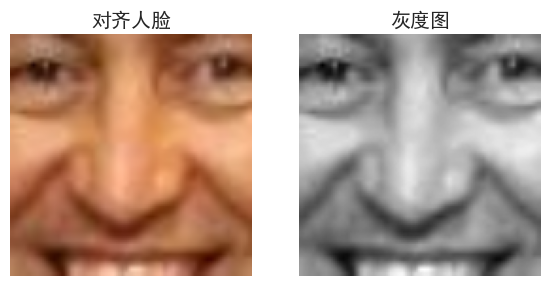

In [23]:
sample = full_df.sample(1, random_state=666).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))

face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(face_gray, cmap="gray")
axes[1].set_title("灰度图")
axes[1].axis("off")

plt.tight_layout()

# ================= 新增：保存为 SCI 级别清晰度 =================
plt.savefig(
    "./results/face_alignment_gray.png",
    dpi=400,                 # 关键：400 PPI
    bbox_inches="tight",     # 去掉多余白边
    pad_inches=0.02          # 论文友好微边距
)
# ===============================================================

plt.show()


In [ ]:
# Otsu 自动阈值分割：自动计算最优阈值，将灰度图转为二值掩膜
# ret 是自动计算的阈值，mask_raw 是 0/255 二值图像
ret, mask_raw = cv2.threshold(
    face_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU  # THRESH_OTSU 自动选择阈值（忽略手动设的 0）
)

print("Otsu 自动阈值 =", ret)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("灰度图")
axes[0].axis("off")

axes[1].imshow(mask_raw, cmap="gray")
axes[1].set_title("初始掩膜 (Otsu)")
axes[1].axis("off")

plt.tight_layout()

# ================= SCI 级别保存 =================
plt.savefig(
    "./results/otsu_mask.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去白边
    pad_inches=0.02          # 论文安全边距
)
# ====================================================

plt.show()

In [ ]:
# 形态学操作：用椭圆结构元素清理二值掩膜
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # 3x3 椭圆结构元素

# 开运算（Opening）：先腐蚀再膨胀，去掉小白点噪声（孤立的前景像素）
mask_open = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN, kernel, iterations=1)

# 闭运算（Closing）：先膨胀再腐蚀，填补小黑洞（孤立的背景像素）
mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel, iterations=2)

# 三步对比：初始掩膜 → 开运算 → 开+闭
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(mask_raw, cmap="gray")
axes[0].set_title("初始掩膜")
axes[0].axis("off")

axes[1].imshow(mask_open, cmap="gray")
axes[1].set_title("开运算后")
axes[1].axis("off")

axes[2].imshow(mask_clean, cmap="gray")
axes[2].set_title("开+闭 后掩膜")
axes[2].axis("off")

plt.tight_layout()

# ================= SCI 论文级保存 =================
plt.savefig(
    "./results/morphology_cleaning.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# 用掩膜将人脸前景从背景中分离
mask_3c = cv2.cvtColor(mask_clean, cv2.COLOR_GRAY2BGR) // 255  # 0/255 → 0/1 的三通道掩膜

# 前景 = 原图 × 掩膜（白色区域保留，黑色区域变黑）
foreground = face * mask_3c

# 背景用灰色填充（将原图转灰度再转三通道，保持同尺寸）
background_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
background_gray = cv2.cvtColor(background_gray, cv2.COLOR_GRAY2BGR)
bg_with_hole = background_gray * (1 - mask_3c)  # 掩膜反选：保留背景中被挖掉的部分

# 最终分割结果 = 前景 + 背景
segmented = foreground + bg_with_hole

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face, "原图", ax=axes[0])
axes[1].imshow(mask_clean, cmap="gray")
axes[1].set_title("最终掩膜")
axes[1].axis("off")
show_rgb(segmented, "掩膜分割效果", ax=axes[2])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/face_segmentation_result.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# K-means 颜色分割：将人脸图像按颜色聚类为 K 个区域
Z = face.reshape((-1, 3)).astype(np.float32)  # 展平为 (N, 3)，每行是 [B, G, R]

K = 3  # 聚类数：将颜色分为 3 类（如肤色、头发、背景）
# 终止条件：最多迭代 20 次，或精度达到 1.0
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
ret, labels, centers = cv2.kmeans(
    Z, K, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS
# Z=数据, K=聚类数, bestLabels=None, criteria=终止条件,
# attempts=5（多次初始化取最优）, flags=随机初始中心
)

# 将每个像素替换为其所属聚类的中心颜色
centers = np.uint8(centers)  # 聚类中心转为 uint8
seg_kmeans = centers[labels.flatten()].reshape(face.shape)  # 用中心颜色替换像素，恢复图像形状

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(seg_kmeans, "K-means 颜色分割 (K=3)", ax=axes[1])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/kmeans_color_segmentation.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

- **目的**：提取轮廓结构（下巴、眼睛、眼镜框等）。
- **实现内容**：
  - 计算 Sobel X/Y、梯度幅值图。
  - Canny 边缘检测。
  - 将边缘叠加到原图上展示。
- **知识点**：一阶/二阶导、Sobel、Canny 各步骤。
- **主要库**：`cv2.Sobel, cv2.Canny, skimage.filters, skimage.feature.canny`。

---

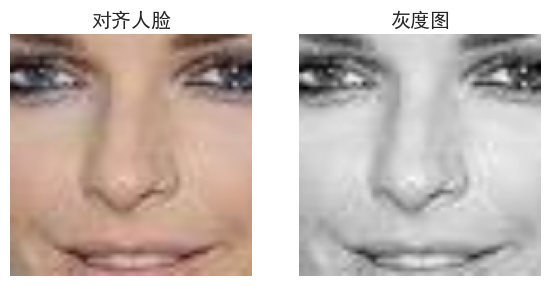

In [28]:
sample = full_df.sample(1, random_state=777).iloc[0]
img_raw = load_image(sample)
face = align_face_by_eyes(img_raw, sample, output_size=(128, 128))
face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(face_gray, cmap="gray")
axes[1].set_title("灰度图")
axes[1].axis("off")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/aligned_face_gray_sample777.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()


In [ ]:
# Sobel 边缘检测：分别计算水平和垂直方向的梯度
# CV_64F 输出浮点数（包含负值），避免 uint8 截断
sobel_x = cv2.Sobel(face_gray, cv2.CV_64F, 1, 0, ksize=3)  # dx=1, dy=0: 水平方向梯度（检测垂直边缘）
sobel_y = cv2.Sobel(face_gray, cv2.CV_64F, 0, 1, ksize=3)  # dx=0, dy=1: 垂直方向梯度（检测水平边缘）

# 梯度幅值 = sqrt(Gx^2 + Gy^2)
grad_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
grad_mag = np.uint8(255 * grad_mag / grad_mag.max())  # 归一化到 0-255

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(np.abs(sobel_x), cmap="gray")  # abs 取绝对值显示
axes[0].set_title("Sobel X")
axes[0].axis("off")

axes[1].imshow(np.abs(sobel_y), cmap="gray")
axes[1].set_title("Sobel Y")
axes[1].axis("off")

axes[2].imshow(grad_mag, cmap="gray")
axes[2].set_title("梯度幅值")
axes[2].axis("off")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/sobel_gradient_visualization.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# Canny 边缘检测：双阈值 + 非极大值抑制
# threshold1=50（低阈值）, threshold2=150（高阈值）
# 梯度 > 高阈值 → 强边缘；低~高之间 → 弱边缘（仅与强边缘相连时保留）；< 低阈值 → 抑制
edges = cv2.Canny(face_gray, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("灰度图")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny 边缘")
axes[1].axis("off")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/canny_edge_detection.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
from skimage.feature import canny

# skimage Canny：sigma=1.5 控制高斯平滑程度，返回 True/False 布尔图
edges_ski = canny(face_gray, sigma=1.5)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(edges_ski, cmap="gray")
axes[0].set_title("skimage Canny")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("OpenCV Canny")
axes[1].axis("off")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/canny_skimage_vs_opencv.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去白边
    pad_inches=0.02          # 期刊安全边距
)
# ===================

In [ ]:
# 将 Canny 边缘叠加到原图上，直观显示边缘位置
edges_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)  # 灰度转三通道

overlay = face.copy()                        # 复制原图
overlay[edges > 0] = (0, 255, 0)             # 边缘像素涂成绿色（BGR 格式）

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(overlay, "边缘叠加 (绿色)", ax=axes[1])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/canny_edge_overlay.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()


### 8. 特征提取（Notebook）
- **目的**：把图像变成特征向量，连接到“机器学习世界”。
- **实现内容**：
  - 基于分割掩膜的形状特征：面积、周长等。
  - 纹理特征：LBP / HOG。
  - 角点特征：Harris 角点或 ORB 关键点。
  - 可选：抽几张图用预训练 CNN 提取特征向量（当作对比）。
- **知识点**：形状特征、纹理特征、局部特征点的概念；图像→向量。
- **主要库**：
  - `skimage.feature.local_binary_pattern, skimage.feature.hog`
  - `- `cv2.cornerHarris, cv2.ORB_create` 等。

In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern, hog


def get_face_and_mask(row, size=(128, 128)):
    """对齐人脸 + Otsu 分割 + 形态学清理，返回 face, gray, mask_clean"""
    img_raw = load_image(row)
    face = align_face_by_eyes(img_raw, row, output_size=size)
    gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    # Otsu 自动阈值分割
    _, mask = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    # 形态学开+闭运算清理掩膜
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel, iterations=2)
    return face, gray, mask_clean


sample = full_df.sample(1, random_state=8).iloc[0]
face, face_gray, mask_clean = get_face_and_mask(sample)

# ========== 形状特征：轮廓面积和周长 ==========
# findContours: 从二值图中提取轮廓
# RETR_EXTERNAL: 只检测外轮廓；CHAIN_APPROX_SIMPLE: 压缩水平/垂直/对角线段
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

area = 0.0
perimeter = 0.0
for cnt in contours:
    area += cv2.contourArea(cnt)         # 轮廓面积（像素数）
    perimeter += cv2.arcLength(cnt, True) # 轮廓周长（True=封闭曲线）

print("形状特征：")
print("  面积 (pixels):", area)
print("  周长 (pixels):", perimeter)
print("  面积占比:", area / (mask_clean.shape[0] * mask_clean.shape[1]))

# 可视化：原图 + 掩膜 + 轮廓叠加
contour_vis = face.copy()
cv2.drawContours(contour_vis, contours, -1, (0, 255, 0), 1)  # -1=画所有轮廓，绿色，线宽1

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_rgb(face, "对齐人脸", ax=axes[0])
axes[1].imshow(mask_clean, cmap="gray")
axes[1].set_title("掩膜")
axes[1].axis("off")
show_rgb(contour_vis, "轮廓叠加", ax=axes[2])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/shape_features_contour.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# LBP（局部二值模式）纹理特征提取
# 对每个像素，比较其与邻域的灰度大小关系，编码为二进制模式
P = 8    # 采样点数（周围 8 个像素）
R = 1    # 采样半径（距离中心 1 像素）
# method="uniform": 统一模式，将出现频率低的模式归为一类，降维
lbp = local_binary_pattern(face_gray, P, R, method="uniform")

# LBP 直方图作为纹理特征向量
n_bins = P + 2  # uniform 模式下有 P+1 种模式（含一个"非均匀"类）
hist_lbp, _ = np.histogram(
    lbp.ravel(),           # 展平为一维
    bins=n_bins,
    range=(0, n_bins),
    density=True           # 归一化为概率密度
)

print("LBP 特征维度:", hist_lbp.shape)       # 10 维特征向量
print("LBP 特征前 10 维:", hist_lbp[:10])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(lbp, cmap="gray")
axes[0].set_title("LBP 图")
axes[0].axis("off")

axes[1].bar(np.arange(n_bins), hist_lbp)     # 柱状图展示特征分布
axes[1].set_title("LBP 直方图特征")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/lbp_texture_features.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# HOG（方向梯度直方图）特征提取
# 将图像划分为小 cell，计算每个 cell 内梯度方向直方图，拼接为全局特征向量
hog_vec, hog_vis = hog(
    face_gray,
    orientations=9,              # 每个 cell 的梯度方向 bin 数（0-180 度分为 9 个）
    pixels_per_cell=(8, 8),     # 每个 cell 为 8x8 像素
    cells_per_block=(2, 2),     # 每个 block 包含 2x2 个 cell
    visualize=True,              # 同时返回可视化图
    block_norm="L2-Hys"         # L2-Hys 归一化：L2 范数 + 截断
)

print("HOG 特征维度:", hog_vec.shape)  # (9*4*15*15,) = 8100 维

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(face_gray, cmap="gray")
axes[0].set_title("灰度图")
axes[0].axis("off")

axes[1].imshow(hog_vis, cmap="gray")  # HOG 可视化：每个 cell 用箭头表示主梯度方向
axes[1].set_title("HOG 可视化")
axes[1].axis("off")

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/hog_feature_visualization.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# Harris 角点检测
# cornerHarris 计算每个像素的 Harris 响应值 R
gray_float = np.float32(face_gray)  # cornerHarris 要求 float32 输入
# blockSize=2: 滑动窗口大小；ksize=3: Sobel 梯度计算核；k=0.04: Harris 公式中的自由参数
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)
harris = cv2.dilate(harris, None)  # 膨胀：使角点更明显，便于可视化

# 阈值筛选：R > th * R_max 的像素视为角点
th = 0.05  # 可以试 0.05~0.1，越小检测到的角点越多
corner_vis = face.copy()
corner_vis[harris > th * harris.max()] = [255, 0, 0]  # 角点涂成红色（BGR 格式）

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(corner_vis, "Harris 角点 (红色)", ax=axes[1])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/harris_corner_detection.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
# Harris 角点检测（v2：更低阈值，检测更多角点）
gray_float = np.float32(face_gray)
harris = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

# 阈值筛选显著角点（阈值降低到 0.01，检测更多角点）
corner_vis = face.copy()
corner_vis[harris > 0.01 * harris.max()] = [0, 0, 255]  # 角点涂成红色（BGR）

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
show_rgb(face, "原图", ax=axes[0])
show_rgb(corner_vis, "Harris 角点 (红色)", ax=axes[1])

plt.tight_layout()

# ================= 新增：SCI 论文级保存 =================
plt.savefig(
    "./results/harris_corner_detection_v2.png",
    dpi=400,                 # 400 PPI / DPI
    bbox_inches="tight",     # 去除多余白边
    pad_inches=0.02          # 期刊安全边距
)
# ======================================================

plt.show()

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as T

# 加载预训练 ResNet18（ImageNet 权重），只加载一次
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.eval()  # 设为评估模式（关闭 Dropout、BatchNorm 的训练行为）

# 去掉最后的全连接分类层，保留到全局平均池化层
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])

# 图像预处理管道（ImageNet 标准化）
transform_cnn = T.Compose([
    T.ToPILImage(),                                          # numpy → PIL Image
    T.Resize((224, 224)),                                    # ResNet 输入尺寸
    T.ToTensor(),                                            # PIL → Tensor [0,1]
    T.Normalize(mean=[0.485, 0.456, 0.406],                 # ImageNet 均值
                std=[0.229, 0.224, 0.225]),                  # ImageNet 标准差
])

# face 是 BGR，需要转成 RGB 后再送入 CNN
face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
inp = transform_cnn(face_rgb).unsqueeze(0)  # 添加 batch 维度 → [1,3,224,224]

with torch.no_grad():  # 不计算梯度（推理模式，节省内存）
    feat = feature_extractor(inp)  # 输出 [1, 512, 1, 1]
feat_vec = feat.view(-1).cpu().numpy()  # 展平为 512 维特征向量

print("ResNet18 特征维度:", feat_vec.shape)
print("前 10 维:", feat_vec[:10])

### 保存为txt格式

In [ ]:
import json
from pathlib import Path

# ========== 功能：将 all.ipynb 中所有 code cell 导出为纯文本 .txt ==========

# ---------- 1) 自动定位 all.ipynb ----------
def find_all_ipynb():
    """从当前工作目录向上搜索 all.ipynb 文件"""
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        cand1 = p / "all.ipynb"
        cand2 = p / "notebooks" / "all.ipynb"
        if cand1.exists():
            return cand1
        if cand2.exists():
            return cand2
    return None

all_nb = find_all_ipynb()
assert all_nb is not None, "没找到 all.ipynb（请确认项目目录结构里有 notebooks/all.ipynb）"

# ---------- 2) 读取 ipynb JSON ----------
with open(all_nb, "r", encoding="utf-8") as f:
    nb = json.load(f)  # ipynb 本质上是 JSON 文件

# ---------- 3) 收集所有 code cell ----------
code_blocks = []
for i, cell in enumerate(nb.get("cells", [])):
    if cell.get("cell_type") == "code":       # 只提取代码单元
        src = "".join(cell.get("source", [])).strip()  # source 是字符串列表，拼接为完整代码
        if src:  # 跳过空代码块
            code_blocks.append(f"# ===== Cell {i} =====\n{src}\n")

# ---------- 4) 输出到 notebooks/results ----------
out_dir = all_nb.parent / "results"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "all_code.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write("\n\n".join(code_blocks))

print(f"读取：{all_nb}")
print(f"导出 code cells：{len(code_blocks)} 个")
print(f"保存到：{out_path}")

In [ ]:
import json
from pathlib import Path

# ========== 功能：将 all.ipynb 的 code cells + src/*.py 源文件合并导出为一个 txt ==========

# =====================================================
# 1. 定位项目根目录 & all.ipynb
# =====================================================
def find_project_root_and_all_ipynb():
    """向上搜索同时包含 notebooks/all.ipynb 和 src/ 目录的项目根目录"""
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        nb = p / "notebooks" / "all.ipynb"
        src = p / "src"
        if nb.exists() and src.exists():
            return p, nb, src
    return None, None, None

project_root, all_nb, src_dir = find_project_root_and_all_ipynb()
assert all_nb is not None, "没找到 notebooks/all.ipynb"
assert src_dir is not None, "没找到 src 目录"

# =====================================================
# 2. 读取 all.ipynb 的 code cells
# =====================================================
with open(all_nb, "r", encoding="utf-8") as f:
    nb = json.load(f)  # ipynb 格式是 JSON

sections = []

# 添加标题分隔符
sections.append("##############################\n"
                "# NOTEBOOK: all.ipynb\n"
                "##############################\n")

# 提取所有非空 code cell
for i, cell in enumerate(nb.get("cells", [])):
    if cell.get("cell_type") == "code":
        src = "".join(cell.get("source", [])).strip()  # 拼接 source 列表
        if src:
            sections.append(
                f"\n# ===== Notebook Cell {i} =====\n{src}\n"
            )

# =====================================================
# 3. 读取 src 下所有 .py 文件
# =====================================================
sections.append("\n\n##############################\n"
                "# SOURCE FILES: src/*.py\n"
                "##############################\n")

py_files = sorted(src_dir.glob("*.py"))  # 按文件名排序

for py in py_files:
    with open(py, "r", encoding="utf-8") as f:
        code = f.read().strip()
    sections.append(
        f"\n# ===== File: src/{py.name} =====\n{code}\n"
    )

# =====================================================
# 4. 输出到 notebooks/results/all_bundle.txt
# =====================================================
out_dir = all_nb.parent / "results"
out_dir.mkdir(exist_ok=True)

out_path = out_dir / "all_bundle.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write("\n".join(sections))

print("导出完成")
print(f"Notebook: {all_nb}")
print(f"Python files: {[p.name for p in py_files]}")
print(f"输出文件: {out_path}")